# AQR quality factor proxy

## 🧭 tl;dr

This standalone notebook tests one publicly described AQR strategy idea: **Hold QUAL, a quality-style ETF proxy, with a one-bar execution delay.**

It is a transparent ETF proxy, not the fund's proprietary implementation.

> Educational research only. This notebook is not investment advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


## 🧭 Context & methods

A strategy is a rule for turning information available at time *t* into a position for a later return. The project shifts positions by one bar, charges transaction costs on exposure changes, and keeps the final 20% of the history untouched.

### Key assumptions

- **Rule:** Hold QUAL, a quality-style ETF proxy, with a one-bar execution delay.
- Adjusted Yahoo Finance closes are used when available; a deterministic demo fallback keeps the notebook runnable offline.
- The benchmark is SPY. Stress windows are descriptive diagnostics, not extra test sets.
- The proxy omits proprietary data, instruments, leverage, financing, borrow, fees, and execution details.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import run_backtest, split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    inverse_volatility_weights,
    run_portfolio_backtest,
)
from src.fund_strategies import volatility_scaled_time_series_momentum_weights
from src.research import metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data

The common-price intersection is used so missing assets cannot silently become zero returns. The data cell prints the actual dates used when the notebook runs.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['QUAL', 'SPY']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=5_000, seed=70, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=71, start='2006-01-01')['close'].rename(t)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '2013-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=5_000, seed=70, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=71, start='2006-01-01')['close'].rename(t)], axis=1)

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')


Data: 2013-07-18 through 2025-12-31 (3,134 common trading days)


## 📚 Public source

The strategy description is based on this public source: [AQR research](https://funds.aqr.com/Insights/Strategies/Understanding-Factor-Investing).

The public description is translated into a simple rule that can be inspected line by line. This should be read as a replication of an idea, not a claim about the fund's live returns.

In [3]:
def make_target(panel):
    return pd.Series(1.0, index=panel.index)

def run_candidate(panel, cost_bps):
    return run_backtest(panel['QUAL'], make_target(panel), transaction_cost_bps=cost_bps, benchmark_returns=panel['SPY'].pct_change().fillna(0.0))


## 📈 Formal test results

The table reports annualized return, volatility, Sharpe, Sortino, drawdown, turnover, and benchmark-relative return. No parameter is selected using this final test period.

In [4]:
result = run_candidate(close, TRANSACTION_COST_BPS)
test_metrics = metrics_for_period(result, splits['test'].index)
test_table = pd.DataFrame([test_metrics], index=['AQR quality factor proxy'])
test_table.style.format({
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
AQR quality factor proxy,18.21%,14.75%,1.21,1.80,-18.00%,1.01,54.41%,0.00,0,51.63%,0.586529,-7.03%


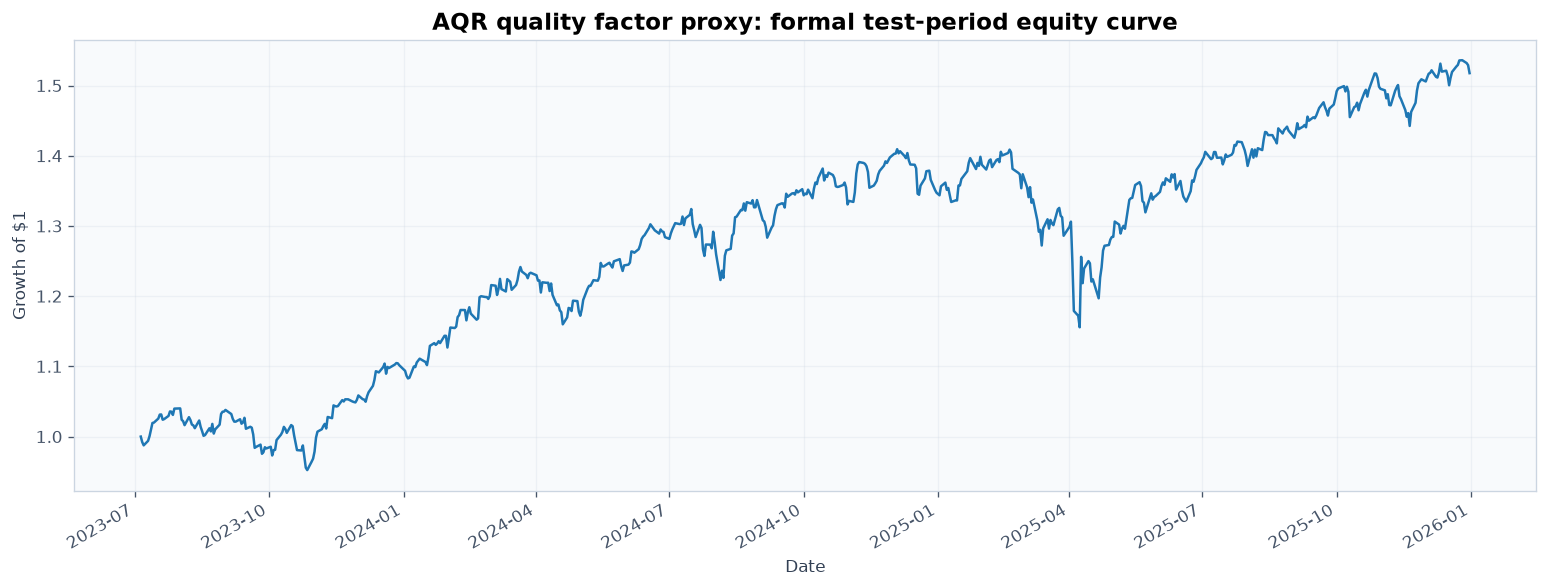

In [5]:
test_index = splits['test'].index
equity = result.frame['equity'].loc[test_index]
(equity / equity.iloc[0]).plot(figsize=(13, 5), title='AQR quality factor proxy: formal test-period equity curve')
plt.ylabel('Growth of $1')
plt.grid(alpha=0.25)
plt.show()

## 🛡️ Robustness and stress diagnostics

These checks show whether the result depends on transaction costs or one crisis window. They are interpretation tools, not new training data.

In [6]:
stress_windows = {'Global Financial Crisis': ('2007-10-01', '2009-03-31'), 'COVID shock': ('2020-02-19', '2020-03-23'), '2022 inflation/rates shock': ('2022-01-03', '2022-10-14')}
stress_rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    returns = result.frame.loc[index, 'net_returns']
    window_equity = (1.0 + returns).cumprod()
    stress_rows.append({'window': window, 'return': window_equity.iloc[-1] - 1.0 if len(window_equity) else float('nan'), 'max_drawdown': (window_equity / window_equity.cummax() - 1.0).min() if len(window_equity) else float('nan')})
stress_table = pd.DataFrame(stress_rows)
display(stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'}))

cost_rows = []
for cost_bps in [0, 10, 25, 50]:
    cost_result = run_candidate(close, cost_bps)
    metrics = metrics_for_period(cost_result, splits['test'].index)
    cost_rows.append({'cost_bps': cost_bps, 'test_return': metrics['total_return_after_costs'], 'test_sharpe': metrics['sharpe_ratio']})
cost_table = pd.DataFrame(cost_rows)
display(cost_table.style.format({'test_return': '{:.2%}', 'test_sharpe': '{:.2f}'}))

,window,return,max_drawdown
0,Global Financial Crisis,nan%,nan%
1,COVID shock,-33.84%,-34.06%
2,2022 inflation/rates shock,-27.87%,-27.67%


,cost_bps,test_return,test_sharpe
0,0,51.63%,1.21
1,10,51.63%,1.21
2,25,51.63%,1.21
3,50,51.63%,1.21


In [7]:
print('Finding: test Sharpe =', round(float(test_metrics['sharpe_ratio']), 2))
print('Finding: test annualized return =', round(float(test_metrics['annualized_return']) * 100, 2), 'percent')
print('Finding: test maximum drawdown =', round(float(test_metrics['max_drawdown']) * 100, 2), 'percent')
print('Finding: annualized turnover =', round(float(test_metrics['annualized_turnover']), 2))

Finding: test Sharpe = 1.21
Finding: test annualized return = 18.21 percent
Finding: test maximum drawdown = -18.0 percent
Finding: annualized turnover = 0.0


## ⚖️ What went well / what went wrong

**What went well:** Quality is easy to explain as a preference for financially stronger companies, and the ETF proxy makes the test reproducible.

**What went wrong:** Quality definitions differ across providers; the proxy may be growth-heavy, can lag speculative bull markets, and is not an exact AQR signal.

**Beginner takeaway:** A backtest is evidence about a rule under stated assumptions—not proof that the fund, proxy, or strategy will make money in the future.